In [159]:
import pandas as pd
df = pd.read_csv('ass.csv')
df.head()

,Unnamed: 0,SEQNUMC,SEQNUMHH,PDAT,PROVWT_D,RDDWT_D,STRATUM,YEAR,AGECPOXR,HAD_CPOX,...,XVRCTY2,XVRCTY3,XVRCTY4,XVRCTY5,XVRCTY6,XVRCTY7,XVRCTY8,XVRCTY9,INS_STAT2_I,INS_BREAK_I
0,1,128521,12852,2,NaN,235.916956,1031,2017,NaN,2,...,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,10741,1074,2,NaN,957.353840,1068,2017,NaN,2,...,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,220011,22001,2,NaN,189.611299,1050,2017,NaN,2,...,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,86131,8613,1,675.430817,333.447418,1040,2017,NaN,2,...,,,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0
4,5,227141,22714,1,482.617748,278.768063,1008,2017,NaN,2,...,,,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0


In [160]:
df = df.set_index('Unnamed: 0')
df.columns = [x.lower() for x in df.columns]
df.head()

,seqnumc,seqnumhh,pdat,provwt_d,rddwt_d,stratum,year,agecpoxr,had_cpox,agegrp,...,xvrcty2,xvrcty3,xvrcty4,xvrcty5,xvrcty6,xvrcty7,xvrcty8,xvrcty9,ins_stat2_i,ins_break_i
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1,128521,12852,2,NaN,235.916956,1031,2017,NaN,2,1,...,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10741,1074,2,NaN,957.353840,1068,2017,NaN,2,1,...,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,220011,22001,2,NaN,189.611299,1050,2017,NaN,2,3,...,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,86131,8613,1,675.430817,333.447418,1040,2017,NaN,2,1,...,,,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0
5,227141,22714,1,482.617748,278.768063,1008,2017,NaN,2,1,...,,,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0


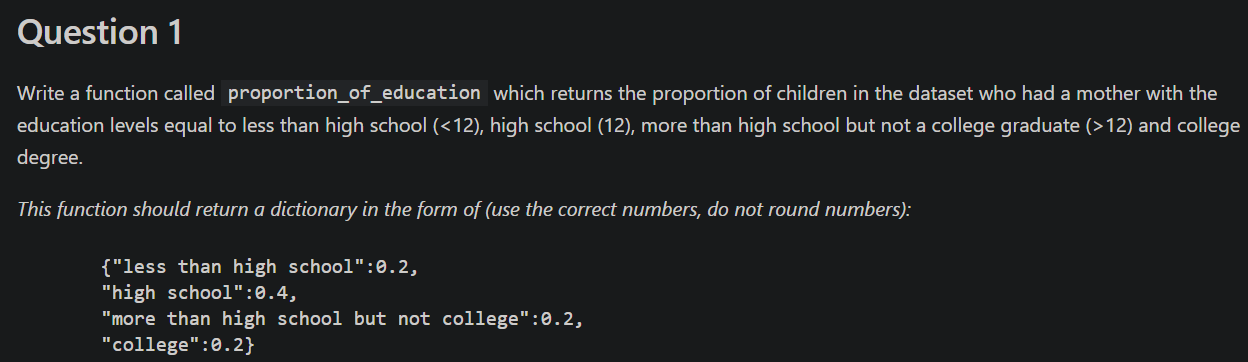

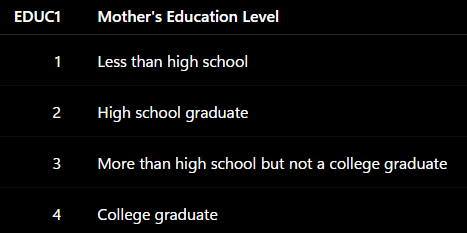

In [161]:
df['educ1'].unique()

array([4, 3, 1, 2])

In [162]:
df['educ1'].dtype

dtype('int64')

In [163]:
ndf = df['educ1'].copy()
ndf = ndf.to_frame('education')
ndf = ndf.reset_index()
ndf.columns = ['index', 'education']
ndf = ndf.set_index('index')
ndf.head()

,education
index,
1,4
2,3
3,3
4,4
5,1


In [164]:
res = ndf.groupby('education').size().to_frame('proportion')
total = len(res)
res['proportion'] = res['proportion'] / total
res

,proportion
education,
1,726.00
2,1226.50
3,1749.75
4,3414.00


In [165]:
d = {}
d['less than high school'] =726.00
d['high school'] = 1226.50
d['more than high school but not college'] = 1749.75
d['college'] = 3414.00

print(d)

{'less than high school': 726.0, 'high school': 1226.5, 'more than high school but not college': 1749.75, 'college': 3414.0}


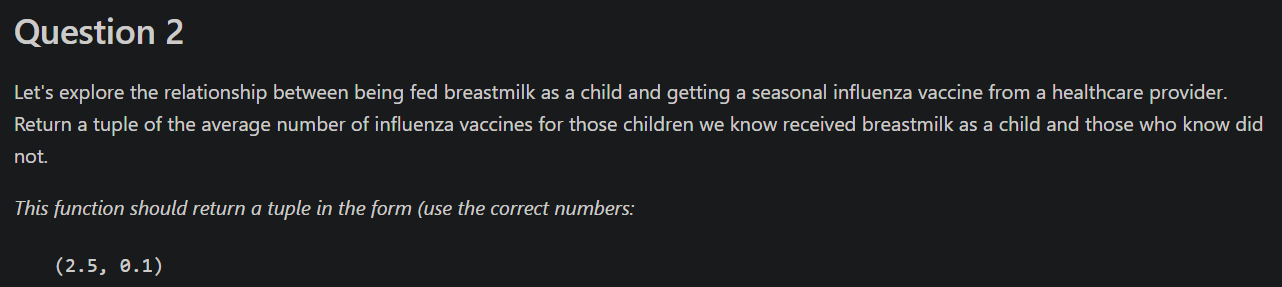

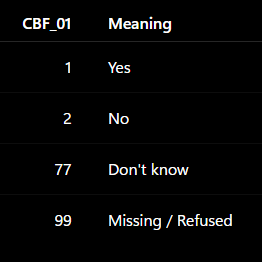

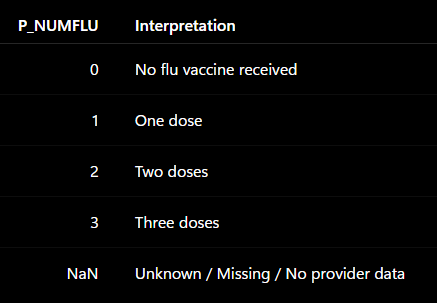

In [166]:
ndf = df[['cbf_01', 'p_numflu']]
ndf = ndf.reset_index()
ndf.columns = ['child','bf','vc']
ndf = ndf.set_index('child')
ndf = ndf.fillna(0)
ndf.head()

,bf,vc
child,,
1,1,0.0
2,2,0.0
3,2,0.0
4,2,3.0
5,1,0.0


In [167]:
ndf.nunique()

bf    4
vc    7
dtype: int64

In [168]:
ndf['bf'].unique()

array([ 1,  2, 99, 77])

In [169]:
ndf['vc'].unique()

array([0., 3., 2., 1., 4., 5., 6.])

In [170]:
ndf = ndf[ndf['bf'] <= 2]
ndf['bf'].unique()

array([1, 2])

In [171]:
ndf['bf'] -= 1
ndf['bf'].unique()

array([0, 1])

In [172]:
ndf['bf'] = ndf['bf'].astype(bool)
ndf['bf'].unique()

array([False,  True])

In [173]:
ndf.head()

,bf,vc
child,,
1,False,0.0
2,True,0.0
3,True,0.0
4,True,3.0
5,False,0.0


In [177]:
ndf['vc'] = ndf['vc'].astype(bool)
ndf['vc'].unique()

array([False,  True])

In [178]:
ndf.head()

,bf,vc
child,,
1,False,False
2,True,False
3,True,False
4,True,True
5,False,False


In [183]:
res = ndf.groupby('bf').size().to_frame('average')
res['average'] = res['average'] / total
res

,average
bf,
False,6065.25
True,1021.25


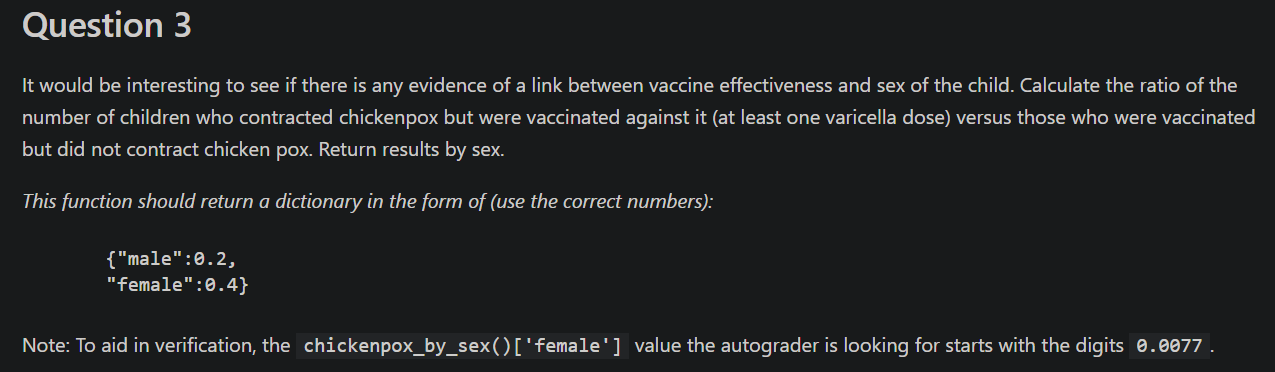